# Eche

Group: Final_Project_Group 1 | Workshop: Performance Metrics Classification (MNIST)

Section: Fashion-MNIST exercise, confusion matrix

This notebook completes the Fashion-MNIST and confusion-matrix questions from the original active-learning notebook. The code uses only packages listed in the supplied `requirements.txt`.

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix
import numpy as np

from src.fashion_analysis import FashionAnalysis

### Exercise: Fashion-MNIST data set

**Question:** Get the Fashion-MNIST data set (the fetch cell is in the original notebook).

In [2]:
fashion_mnist = fetch_openml(
    "Fashion-MNIST",
    version=1,
    as_frame=False,
    parser="auto",
    n_retries=5,
    delay=2
)

X_fashion, y_fashion = fashion_mnist.data, fashion_mnist.target

In [3]:
print("X_fashion shape:", X_fashion.shape)
print("y_fashion shape:", y_fashion.shape)
print("First 10 labels:", y_fashion[:10])

X_fashion shape: (70000, 784)
y_fashion shape: (70000,)
First 10 labels: ['9' '0' '0' '3' '0' '2' '7' '2' '5' '5']


**Visual needed:** Grid of sample Fashion-MNIST images with their labels.

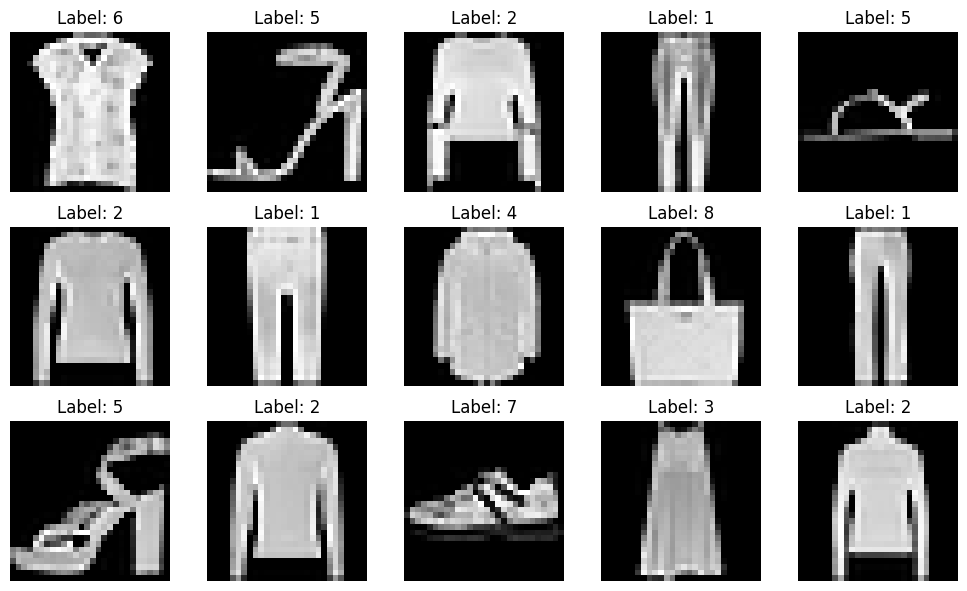

In [4]:
FashionAnalysis.plot_samples(X_fashion, y_fashion)

**Question:** Preprocess the data set (split into train and test, create the binary target). Which clothing category did you choose as the positive class, and why?

**Answer:**

I used the same preprocessing structure as the MNIST example: the first 60,000 observations are used for training and the remaining 10,000 are used for testing. I converted the original 10-class Fashion-MNIST target into a binary target.

I chose **Sneaker** as the positive class (`label = "7"`). The reason is that Sneaker is a clearly defined clothing category and makes the binary task easy to interpret: `True` means the image is a sneaker and `False` means it is another Fashion-MNIST category. This also follows the original notebook's approach of selecting one class of interest and grouping all other classes into the negative class.

In [5]:
X_fashion_train, X_fashion_test = X_fashion[:60000], X_fashion[60000:]
y_fashion_train, y_fashion_test = y_fashion[:60000], y_fashion[60000:]

positive_class = '7'  # Sneaker
y_fashion_train_binary, y_fashion_test_binary = FashionAnalysis.make_binary_targets(
    y_fashion_train, y_fashion_test, positive_class=positive_class
)

print('Positive class: Sneaker (label 7)')
print('Training samples:', len(X_fashion_train))
print('Test samples:', len(X_fashion_test))
print('Positive training samples:', y_fashion_train_binary.sum())
print('Negative training samples:', (~y_fashion_train_binary).sum())

Positive class: Sneaker (label 7)
Training samples: 60000
Test samples: 10000
Positive training samples: 6000
Negative training samples: 54000


**Question:** Train a model.

In [6]:
fashion_sgd_clf = FashionAnalysis.train_sgd(
    X_fashion_train,
    y_fashion_train_binary,
    random_state=42
)

# Fit the model once on the complete training split, matching the MNIST workflow.
fashion_test_predictions = fashion_sgd_clf.predict(X_fashion_test)
print('Model trained successfully.')

Model trained successfully.


**Question:** Evaluate the model (accuracy, DummyClassifier comparison, confusion matrix).

In [7]:
fashion_cv_results, fashion_cv_predictions, fashion_cm = FashionAnalysis.evaluate_model(
    fashion_sgd_clf,
    X_fashion_train,
    y_fashion_train_binary,
    cv=3
)

fashion_dummy, fashion_dummy_results = FashionAnalysis.evaluate_dummy(
    X_fashion_train,
    y_fashion_train_binary,
    cv=3
)

print('SGDClassifier accuracy by fold:', fashion_cv_results['test_score'])
print('SGDClassifier mean accuracy:', fashion_cv_results['test_score'].mean())
print('DummyClassifier accuracy by fold:', fashion_dummy_results['test_score'])
print('DummyClassifier mean accuracy:', fashion_dummy_results['test_score'].mean())
print('Fashion-MNIST confusion matrix:')
print(fashion_cm)

SGDClassifier accuracy by fold: [0.97885 0.97505 0.964  ]
SGDClassifier mean accuracy: 0.9726333333333333
DummyClassifier accuracy by fold: [0.9 0.9 0.9]
DummyClassifier mean accuracy: 0.9
Fashion-MNIST confusion matrix:
[[52767  1233]
 [  409  5591]]


**Visual needed:** Confusion matrix heatmap for the Fashion-MNIST model.

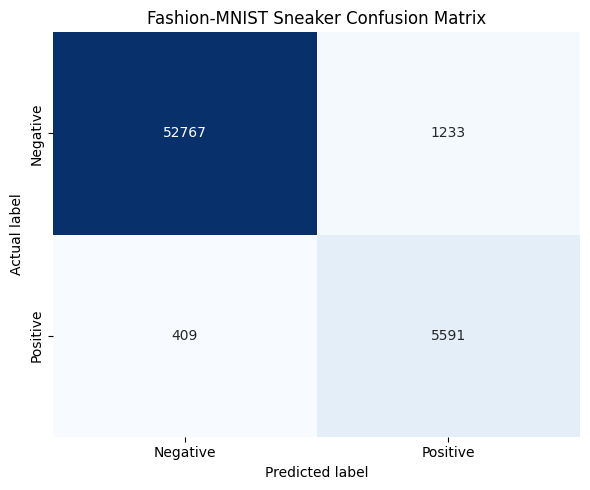

In [8]:
FashionAnalysis.plot_confusion_matrix(fashion_cm, title="Fashion-MNIST Sneaker Confusion Matrix")

**Question:** Are you able to replicate the process? Provide your insights.

**Answer:**

Yes. The process can be replicated using Fashion-MNIST because the dataset has the same basic structure as MNIST: each image is represented by 784 pixel features and each image has a class label.

For this exercise, I selected Sneaker (label 7) as the positive class and converted the original ten-class problem into a binary classification problem. I then trained an SGDClassifier, evaluated it using 3-fold cross-validation, compared its accuracy with a DummyClassifier, and generated a confusion matrix.

The SGDClassifier achieved a mean cross-validation accuracy of approximately 97.26%, while the DummyClassifier achieved 90%. This shows that the SGDClassifier performed better than the baseline. The confusion matrix also provides additional information by showing the true positives, true negatives, false positives, and false negatives.

### Confusion matrix

**Question:** What are the required arguments that the `confusion_matrix` function expects?

**Answer:**

The required arguments are `y_true` and `y_pred`.

- `y_true` is the ground-truth/actual class label for each sample.
- `y_pred` is the predicted class label for each sample.

In this notebook, an example is `confusion_matrix(y_train_5, y_train_pred)`, where `y_train_5` contains the actual binary labels and `y_train_pred` contains the classifier's predictions. Other parameters such as `labels`, `sample_weight`, and `normalize` are optional.

**Question:** What is the output of this function, specifically for a binary classifier such as the one tested here?

**Answer:**

For a binary classifier, `confusion_matrix` returns a **2 × 2 NumPy array**. With the default label ordering, the rows represent the actual classes and the columns represent the predicted classes.

For a binary problem with negative class `0`/`False` and positive class `1`/`True`, the layout is:

`[[TN, FP],`
 ` [FN, TP]]`

where TN is true negative, FP is false positive, FN is false negative, and TP is true positive. Each cell contains the number of samples that fall into that actual/predicted combination.

**Question:** What is the meaning of each value in both of the confusion matrices returned in the original notebook?

**Answer:**

The original notebook returns two binary confusion matrices.

**1. SGDClassifier predictions:**

```text
[[53892,   687],
 [ 1891,  3530]]
```

Using the layout `[[TN, FP], [FN, TP]]`:

- **53,892 TN:** the actual digit was not `5` and the model correctly predicted not `5`.
- **687 FP:** the actual digit was not `5`, but the model incorrectly predicted `5`.
- **1,891 FN:** the actual digit was `5`, but the model incorrectly predicted not `5`.
- **3,530 TP:** the actual digit was `5` and the model correctly predicted `5`.

**2. Perfect predictions in the original notebook:**

```text
[[54579,     0],
 [    0,  5421]]
```

Here the predictions are set equal to the true labels, so every prediction is correct:

- **54,579 TN:** actual not `5`, predicted not `5`.
- **0 FP:** no non-`5` digit was incorrectly predicted as `5`.
- **0 FN:** no actual `5` was missed.
- **5,421 TP:** every actual `5` was correctly predicted as `5`.

The second matrix represents perfect classification because all observations are on the diagonal and both off-diagonal error counts are zero.

**Visual needed:** Heatmap of the MNIST confusion matrix (optional, supports the previous answer).

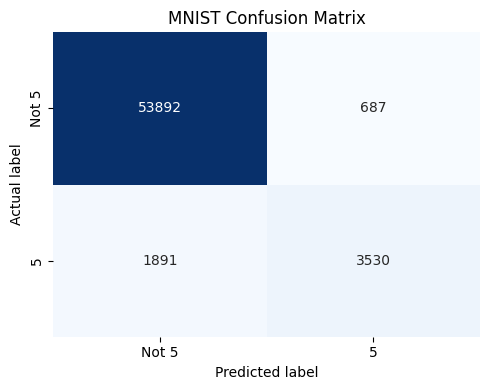

In [9]:
# The original notebook produced this MNIST matrix:
mnist_cm = np.array([[53892, 687], [1891, 3530]])

FashionAnalysis.plot_mnist_confusion_matrix(mnist_cm)